In [97]:
# ── CELL 1: Check GPU ──────────────────────────────────────
import torch
print("GPU:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU: True
Device: Tesla T4


In [98]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [99]:
# create folders for dataset


import os

base = "/kaggle/working/dataset"

splits = ["train", "test"]
classes = ['0','1','2','3','4','5','6','7','8','9',
           'plus','minus','multiply','divide','equal',
           'x','y','a','b']

for split in splits:
    for cls in classes:
        os.makedirs(f"{base}/{split}/{cls}", exist_ok=True)

print("Dataset folders created")

Dataset folders created


In [100]:
import shutil
shutil.rmtree("/kaggle/working/dataset/train/z", ignore_errors=True) # to remove unused folders
print("Deleted")


Deleted


In [101]:
import pandas as pd
import numpy as np
import os
from PIL import Image
from tqdm.notebook import tqdm

df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

# 80/20 split
split_idx = int(len(df) * 0.8)
train_split = df[:split_idx]
test_split  = df[split_idx:]

print(f"Train: {len(train_split)}, Test: {len(test_split)}")

base = "/kaggle/working/dataset"

# Create directories
for split in ['train', 'test']:
    for label in range(10):
        os.makedirs(f"{base}/{split}/{label}", exist_ok=True)

# Save train as PNG
for idx, row in tqdm(train_split.iterrows(), total=len(train_split), desc="Saving Train"):
    label = row['label']
    pixels = row.drop('label').values.astype(np.uint8).reshape(28, 28)
    img = Image.fromarray(pixels)
    img.save(f"{base}/train/{label}/mnist_{idx}.png")

# Save test as PNG
for idx, row in tqdm(test_split.iterrows(), total=len(test_split), desc="Saving Test"):
    label = row['label']
    pixels = row.drop('label').values.astype(np.uint8).reshape(28, 28)
    img = Image.fromarray(pixels)
    img.save(f"{base}/test/{label}/mnist_{idx}.png")

print("Done!")

Train: 33600, Test: 8400


Saving Train:   0%|          | 0/33600 [00:00<?, ?it/s]

Saving Test:   0%|          | 0/8400 [00:00<?, ?it/s]

Done!


In [102]:
import os

base = "/kaggle/working/dataset"

for split in ['train', 'test']:
    print(f"\n{split.upper()}:")
    total = 0
    folders = os.listdir(f"{base}/{split}")
    for folder in sorted(folders):
        count = len(os.listdir(f"{base}/{split}/{folder}"))
        total += count
        print(f"  Label {folder}: {count} files")
    print(f"  TOTAL: {total} files")


TRAIN:
  Label 0: 3756 files
  Label 1: 4183 files
  Label 2: 3722 files
  Label 3: 3901 files
  Label 4: 3681 files
  Label 5: 3394 files
  Label 6: 3770 files
  Label 7: 3943 files
  Label 8: 3704 files
  Label 9: 3785 files
  Label a: 3356 files
  Label b: 3356 files
  Label divide: 494 files
  Label equal: 507 files
  Label minus: 524 files
  Label multiply: 461 files
  Label plus: 476 files
  Label x: 3110 files
  Label y: 3081 files
  TOTAL: 53204 files

TEST:
  Label 0: 971 files
  Label 1: 1063 files
  Label 2: 888 files
  Label 3: 991 files
  Label 4: 917 files
  Label 5: 834 files
  Label 6: 948 files
  Label 7: 991 files
  Label 8: 913 files
  Label 9: 950 files
  Label a: 840 files
  Label b: 840 files
  Label divide: 124 files
  Label equal: 127 files
  Label minus: 131 files
  Label multiply: 116 files
  Label plus: 120 files
  Label x: 779 files
  Label y: 771 files
  TOTAL: 13314 files


In [103]:
import pandas as pd
import numpy as np
import os
from PIL import Image
from tqdm.notebook import tqdm

train_df = pd.read_csv('/kaggle/input/datasets/crawford/emnist/emnist-letters-train.csv', header=None)
test_df  = pd.read_csv('/kaggle/input/datasets/crawford/emnist/emnist-letters-test.csv',  header=None)

df = pd.concat([train_df, test_df], ignore_index=True)

target_labels = {1: 'a', 2: 'b', 24: 'x', 25: 'y'}
df = df[df[0].isin(target_labels.keys())]

base = "/kaggle/working/dataset"

for label_id, letter in target_labels.items():
    subset = df[df[0] == label_id]
    split_idx = int(len(subset) * 0.8)
    train_split = subset[:split_idx]
    test_split  = subset[split_idx:]

    os.makedirs(f"{base}/train/{letter}", exist_ok=True)
    os.makedirs(f"{base}/test/{letter}",  exist_ok=True)

    for idx, row in tqdm(train_split.iterrows(), total=len(train_split), desc=f"Train {letter}"):
        pixels = row.drop(0).values.astype(np.uint8).reshape(28, 28)
        img = Image.fromarray(pixels)
        img.save(f"{base}/train/{letter}/emnist_{idx}.png")

    for idx, row in tqdm(test_split.iterrows(), total=len(test_split), desc=f"Test {letter}"):
        pixels = row.drop(0).values.astype(np.uint8).reshape(28, 28)
        img = Image.fromarray(pixels)
        img.save(f"{base}/test/{letter}/emnist_{idx}.png")

print("Done!")

Train a:   0%|          | 0/3356 [00:00<?, ?it/s]

Test a:   0%|          | 0/840 [00:00<?, ?it/s]

Train b:   0%|          | 0/3356 [00:00<?, ?it/s]

Test b:   0%|          | 0/840 [00:00<?, ?it/s]

Train x:   0%|          | 0/2749 [00:00<?, ?it/s]

Test x:   0%|          | 0/688 [00:00<?, ?it/s]

Train y:   0%|          | 0/2762 [00:00<?, ?it/s]

Test y:   0%|          | 0/691 [00:00<?, ?it/s]

Done!


In [104]:
for split in ['train', 'test']:
    classes = sorted(os.listdir(f"dataset/{split}"))
    print(f"{split}: {classes}")
    print(len(classes))



train: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'divide', 'equal', 'minus', 'multiply', 'plus', 'x', 'y']
19
test: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'divide', 'equal', 'minus', 'multiply', 'plus', 'x', 'y']
19


In [105]:
import os, struct, numpy as np
from PIL import Image
from pathlib import Path
import torch, torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, ConcatDataset
from tqdm.notebook import tqdm
import torch.nn.functional as F

In [106]:
import os
import shutil
from tqdm.notebook import tqdm

src_base = '/kaggle/input/datasets/sagyamthapa/handwritten-math-symbols/dataset'
dst_base = '/kaggle/working/dataset'

# map folder names to your label names
label_map = {
    '0':'0', '1':'1', '2':'2', '3':'3', '4':'4',
    '5':'5', '6':'6', '7':'7', '8':'8', '9':'9',
    'add':'plus', 'sub':'minus', 'mul':'multiply',
    'div':'divide', 'eq':'equal',
    'x':'x', 'y':'y'}

for src_label, dst_label in label_map.items():
    files = os.listdir(f"{src_base}/{src_label}")
    split_idx = int(len(files) * 0.8)
    train_files = files[:split_idx]
    test_files  = files[split_idx:]

    os.makedirs(f"{dst_base}/train/{dst_label}", exist_ok=True)
    os.makedirs(f"{dst_base}/test/{dst_label}",  exist_ok=True)

    for f in tqdm(train_files, desc=f"Train {dst_label}"):
        shutil.copy(f"{src_base}/{src_label}/{f}", f"{dst_base}/train/{dst_label}/{f}")

    for f in tqdm(test_files, desc=f"Test {dst_label}"):
        shutil.copy(f"{src_base}/{src_label}/{f}", f"{dst_base}/test/{dst_label}/{f}")

print("Done!")

Train 0:   0%|          | 0/476 [00:00<?, ?it/s]

Test 0:   0%|          | 0/119 [00:00<?, ?it/s]

Train 1:   0%|          | 0/449 [00:00<?, ?it/s]

Test 1:   0%|          | 0/113 [00:00<?, ?it/s]

Train 2:   0%|          | 0/346 [00:00<?, ?it/s]

...

Train x:   0%|          | 0/361 [00:00<?, ?it/s]

Test x:   0%|          | 0/91 [00:00<?, ?it/s]

Train y:   0%|          | 0/319 [00:00<?, ?it/s]

Test y:   0%|          | 0/80 [00:00<?, ?it/s]

Done!


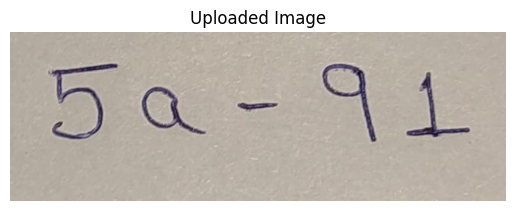

In [107]:
import cv2
import matplotlib.pyplot as plt

# load image
image = cv2.imread("/kaggle/input/datasets/jiggistyle/equation/eq1.jpeg")

# convert BGR to RGB , because opencv user bgr as defaut and others as rgb
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()


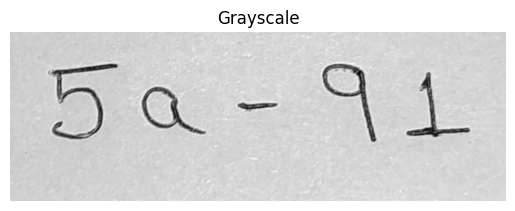

In [108]:
# covert to gray
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.show()

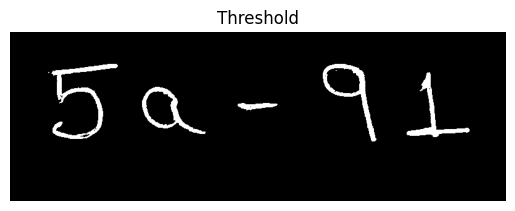

In [109]:
# covert to black and white / thrasholding image / binary image
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)  # cv2,threshold(gray_img, thresh, max_value , thresholding type) it returns rit(thresh , not important),thresh_img

plt.imshow(thresh, cmap="gray")
plt.title("Threshold")
plt.axis("off")
plt.show()

In [110]:
# detect charcchters or contours
contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)


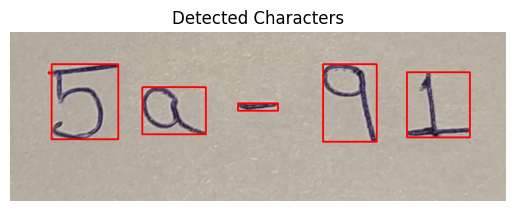

In [111]:
# bounding boxex . visulaizezs the detected charchteds
import numpy as np

image_copy = image.copy()

boxes = []

for cnt in contours:

    x,y,w,h = cv2.boundingRect(cnt)

    if w*h > 100:  # to remove dust or very small contures

      boxes.append((x,y,w,h))

    cv2.rectangle(image_copy,(x,y),(x+w,y+h),(255,0,0),2)

plt.imshow(image_copy)
plt.title("Detected Characters")
plt.axis("off")
plt.show()

In [112]:
# sort boxes
boxes = sorted(boxes, key=lambda a: a[0])  # from left to right , sort x coordinate wise ,  a varible is a[0] of (x,y,w,h)
boxes

[(67, 53, 108, 121),
 (214, 90, 103, 76),
 (369, 116, 65, 12),
 (507, 53, 87, 125),
 (643, 66, 102, 105)]

In [113]:
#crop each charchter
characters = []

for (x, y, w, h) in boxes:
    #padding
    pad = 10
    x1 = max(x - pad, 0)
    y1 = max(y - pad, 0)
    x2 = min(x + w + pad, thresh.shape[1])
    y2 = min(y + h + pad, thresh.shape[0])
    char = thresh[y:y+h, x:x+w]   # numpy slicing its image[row,colomn] not image[x,y], crop from threshold image , from y to y+height , and x to x+width
    characters.append(char)


In [114]:
#resize
resized_chars = []

for char in characters:
    h, w = char.shape
    size = max(h, w) + 20          # make square with margin
    canvas = np.zeros((size, size), dtype=np.uint8)
    y_off = (size - h) // 2
    x_off = (size - w) // 2
    canvas[y_off:y_off+h, x_off:x_off+w] = char
    char = cv2.resize(canvas, (28, 28))
    resized_chars.append(char)


In [115]:
# normalize for cnn
normalized_chars = []

for char in resized_chars:
    char = char / 255.0          # [0, 1]
    char = (char - 0.5) / 0.5   # [-1, 1]
    normalized_chars.append(char)

In [116]:
# convert to tensors
import torch

tensor_chars = []

for char in normalized_chars:
    char = np.array(char, dtype=np.float32)
    char = np.expand_dims(char, axis=0)   # add channel dim → (1,28,28)
    char = torch.tensor(char)
    tensor_chars.append(char)



In [117]:
# make batches
input_batch = torch.stack(tensor_chars)
input_batch.size()

torch.Size([5, 1, 28, 28])

In [118]:
# ── CELL 2: Imports ────────────────────────────────────────
import os, struct, numpy as np
from PIL import Image
from pathlib import Path
import torch, torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, ConcatDataset
from tqdm.notebook import tqdm
import torch.nn.functional as F

In [119]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CharCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 7 * 7, 256), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [120]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler

train_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((28, 28)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
test_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.ImageFolder("/kaggle/working/dataset/train", transform=train_transform)
test_data  = datasets.ImageFolder("/kaggle/working/dataset/test",  transform=test_transform)

targets = torch.tensor(train_data.targets)
class_counts = torch.bincount(targets)
weights = 1.0 / class_counts.float()
sample_weights = weights[targets]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_data, batch_size=64, sampler=sampler,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=True)

num_classes = len(train_data.classes)
print("Classes:", train_data.classes)
print("num_classes:", num_classes)

Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'divide', 'equal', 'minus', 'multiply', 'plus', 'x', 'y']
num_classes: 19


In [121]:
labels = train_loader.dataset.classes
[ '0','1','2','3','4','5','6','7','8','9', 'a','b','divide','equal','minus','multiply','plus','x','y' ]

['0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 'a',
 'b',
 'divide',
 'equal',
 'minus',
 'multiply',
 'plus',
 'x',
 'y']

In [122]:
num_classes = len(labels)
num_classes

19

In [123]:
model = CharCNN(num_classes)
model.eval()

CharCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Dropout2d(p=0.25, inplace=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout2d(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=3136, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=19, bias=True)
  )
)

In [124]:
# num_classes = len(label_map)
# num_classes


In [125]:
torch.backends.cudnn.benchmark = True

In [126]:
import torch.optim as optim
from tqdm.notebook import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model     = CharCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

epochs = 20
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")
    for images, labels in loop:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        correct += outputs.max(1)[1].eq(labels).sum().item()
        total += labels.size(0)
        loop.set_postfix(loss=loss.item())

    scheduler.step()

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            val_correct += model(images).max(1)[1].eq(labels).sum().item()
            val_total += labels.size(0)

    print(f"Epoch {epoch+1:2d} | Loss: {running_loss/len(train_loader):.4f} "
          f"| Train: {100.*correct/total:.2f}% "
          f"| Val: {100.*val_correct/val_total:.2f}% "
          f"| LR: {scheduler.get_last_lr()[0]:.5f}")

Device: cuda


Epoch [1/20]:   0%|          | 0/832 [00:00<?, ?it/s]

Epoch  1 | Loss: 1.4683 | Train: 69.72% | Val: 93.54% | LR: 0.00100


Epoch [2/20]:   0%|          | 0/832 [00:00<?, ?it/s]

Epoch  2 | Loss: 1.0431 | Train: 88.42% | Val: 96.12% | LR: 0.00100


...

Epoch 18 | Loss: 0.7625 | Train: 97.35% | Val: 98.90% | LR: 0.00025


Epoch [19/20]:   0%|          | 0/832 [00:00<?, ?it/s]

Epoch 19 | Loss: 0.7592 | Train: 97.39% | Val: 98.89% | LR: 0.00025


Epoch [20/20]:   0%|          | 0/832 [00:00<?, ?it/s]

Epoch 20 | Loss: 0.7548 | Train: 97.60% | Val: 98.90% | LR: 0.00025


In [127]:
model.eval()
correct = 0
total = 0
class_correct = [0] * num_classes
class_total   = [0] * num_classes

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
        for i in range(len(labels)):
            l = labels[i].item()
            class_correct[l] += (predicted[i] == labels[i]).item()
            class_total[l]   += 1

print(f"\nOverall Accuracy: {100.*correct/total:.2f}%\n")
classes = train_loader.dataset.classes
for i in range(num_classes):
    if class_total[i] > 0:
        print(f"  {classes[i]:>10s}: {100.*class_correct[i]/class_total[i]:6.2f}%  ({class_total[i]} samples)")

Evaluating:   0%|          | 0/209 [00:00<?, ?it/s]


Overall Accuracy: 98.90%

           0:  99.38%  (971 samples)
           1:  98.87%  (1063 samples)
           2:  99.55%  (888 samples)
           3:  98.99%  (991 samples)
           4:  98.58%  (917 samples)
           5:  99.28%  (834 samples)
           6:  99.89%  (948 samples)
           7:  99.29%  (991 samples)
           8:  97.70%  (913 samples)
           9:  98.21%  (949 samples)
           a:  99.64%  (840 samples)
           b:  98.69%  (840 samples)
      divide: 100.00%  (124 samples)
       equal:  99.21%  (127 samples)
       minus: 100.00%  (131 samples)
    multiply:  98.28%  (116 samples)
        plus: 100.00%  (120 samples)
           x:  98.20%  (779 samples)
           y:  97.67%  (771 samples)


In [128]:
# predict eq
model.eval()
classes = train_data.classes

display_map = {
    'plus': '+', 'minus': '-', 'multiply': '×',
    'divide': '÷', 'equal': '=',
    '0':'0','1':'1','2':'2','3':'3','4':'4',
    '5':'5','6':'6','7':'7','8':'8','9':'9',
    'a':'a','b':'b','x':'x','y':'y'
}

with torch.no_grad():
    input_batch = input_batch.to(device)
    outputs = model(input_batch)
    pred_indices = outputs.argmax(dim=1).cpu().tolist()

equation = ""
for idx in pred_indices:
    pred_class = classes[idx]
    equation += display_map.get(pred_class, pred_class)

print("Detected equation:", equation)

Detected equation: 59591


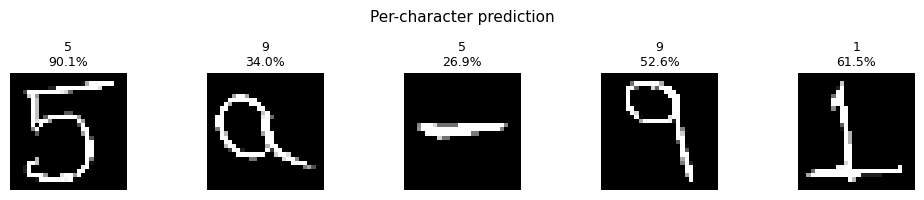

In [129]:
# visualize exactly what each character crop looks like after preprocessing
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(tensor_chars), figsize=(2*len(tensor_chars), 2))
for i, t in enumerate(tensor_chars):
    img = t.squeeze().numpy()          # [28,28]
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    
    # show what model predicted
    with torch.no_grad():
        out = model(t.unsqueeze(0).to(device))
        probs = torch.softmax(out, dim=1)
        top1 = probs.argmax().item()
        conf = probs.max().item()
    axes[i].set_title(f"{display_map.get(classes[top1], classes[top1])}\n{conf*100:.1f}%", fontsize=9)

plt.suptitle("Per-character prediction", fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
git init
git remote add origin https://github.com//yourrepo.git
git add .
git commit -m "good progress"
git push -u origin main